# Moroccan Prepaid Churn — Exploratory Data Analysis

**Dataset**: Expresso Churn (Zindi)  
**Author**: Souhail BOURHIM  
**Notebook**: `01_eda.ipynb`

### Objectives
1. Understand data shape, types, and quality (missing values, duplicates)
2. Characterise the target variable — churn rate and class imbalance
3. Profile numeric features: distributions, skewness, outliers
4. Profile categorical features: cardinality, churn rate per group
5. Correlation analysis and multicollinearity check
6. Document key EDA findings to drive feature engineering decisions

In [1]:
import sys
from pathlib import Path

# make src importable from the notebook
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from src.data.ingestion import load_train, load_test, load_variable_definitions

# ── aesthetics ────────────────────────────────────────────────────────────────
PALETTE = {'churn': '#E63946', 'retain': '#457B9D'}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
print('Environment OK')

Environment OK


## 1. Data Loading

In [2]:
train = load_train()
test  = load_test()

print(f'Train : {train.shape[0]:>10,} rows × {train.shape[1]} cols')
print(f'Test  : {test.shape[0]:>10,} rows × {test.shape[1]} cols')
train.head(3)

Train :  2,154,048 rows × 19 cols
Test  :    380,127 rows × 18 cols


,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
0,00000bfd7d50f01092811bc0c8d7b0d6fe7c3596,FATICK,K > 24 month,4250.0000,15.0000,4251.0000,1417.0000,17.0000,4.0000,388.0000,46.0000,1.0000,1.0000,2.0000,NO,54.0000,On net 200F=Unlimited _call24H,8.0000,0
1,00000cb4a5d760de88fecb38e2f71b7bec52e834,NaN,I 18-21 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,4.0000,NaN,NaN,1
2,00001654a9d9f96303d9969d0a4a851714a4bb57,NaN,K > 24 month,3600.0000,2.0000,1020.0000,340.0000,2.0000,NaN,90.0000,46.0000,7.0000,NaN,NaN,NO,17.0000,On-net 1000F=10MilF;10d,1.0000,0


In [3]:
# Column types
train.dtypes.to_frame('dtype').assign(
    nunique=train.nunique(),
    pct_missing=(train.isna().mean() * 100).round(2)
).sort_values('pct_missing', ascending=False)

,dtype,nunique,pct_missing
ZONE2,float32,486,93.6500
ZONE1,float32,612,92.1200
TIGO,float32,1315,59.8900
DATA_VOLUME,float32,41550,49.2300
FREQ_TOP_PACK,float32,245,41.9000
TOP_PACK,category,140,41.9000
ORANGE,float32,3167,41.5600
REGION,category,14,39.4300
ON_NET,float32,9884,36.5200
MONTANT,float32,6540,35.1300


## 2. Missing Value Analysis

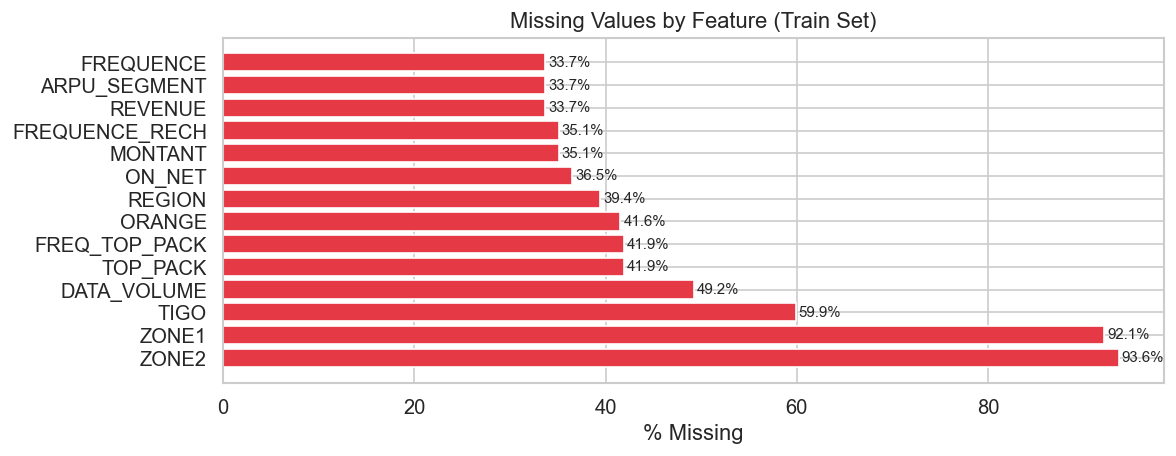

,n_missing,pct
ZONE2,2017224,93.6481
ZONE1,1984327,92.1208
TIGO,1290016,59.8880
DATA_VOLUME,1060433,49.2298
TOP_PACK,902594,41.9022
FREQ_TOP_PACK,902594,41.9022
ORANGE,895248,41.5612
REGION,849299,39.4280
ON_NET,786675,36.5208
MONTANT,756739,35.1310


In [4]:
missing = (
    train.isna()
    .sum()
    .to_frame('n_missing')
    .assign(pct=lambda df: df.n_missing / len(train) * 100)
    .query('n_missing > 0')
    .sort_values('pct', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(missing.index, missing['pct'], color='#E63946', edgecolor='white')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Feature (Train Set)')
for i, (_, row) in enumerate(missing.iterrows()):
    ax.text(row['pct'] + 0.3, i, f"{row['pct']:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

missing

In [5]:
# Are missings MCAR, MAR, or MNAR?
# Check if missingness correlates with churn
miss_cols = missing.index.tolist()
churn_vs_miss = {}
for col in miss_cols:
    mask = train[col].isna()
    churn_missing = train.loc[mask, 'CHURN'].mean()
    churn_present = train.loc[~mask, 'CHURN'].mean()
    churn_vs_miss[col] = {
        'churn_rate_when_missing': round(churn_missing, 4),
        'churn_rate_when_present': round(churn_present, 4),
        'n_missing': int(mask.sum()),
    }

pd.DataFrame(churn_vs_miss).T.sort_values('churn_rate_when_missing', ascending=False)

,churn_rate_when_missing,churn_rate_when_present,n_missing
REVENUE,0.4501,0.0541,726048.0000
ARPU_SEGMENT,0.4501,0.0541,726048.0000
FREQUENCE,0.4501,0.0541,726048.0000
REGION,0.4480,0.0180,849299.0000
MONTANT,0.4415,0.0500,756739.0000
FREQUENCE_RECH,0.4415,0.0500,756739.0000
ON_NET,0.4231,0.0520,786675.0000
ORANGE,0.3944,0.0404,895248.0000
TOP_PACK,0.3919,0.0402,902594.0000
FREQ_TOP_PACK,0.3919,0.0402,902594.0000


## 3. Target Variable — Churn Distribution

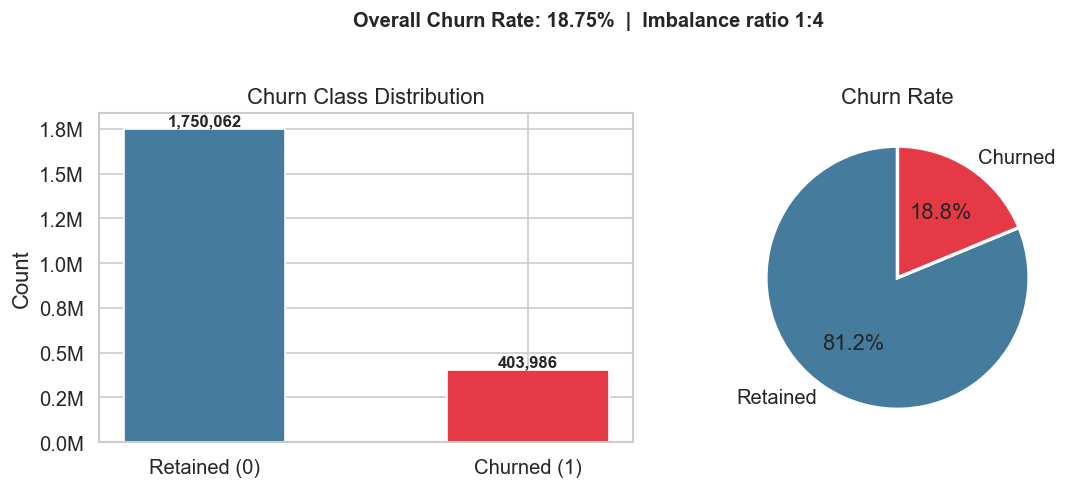

Churn rate      : 0.1875 (18.75%)
Class imbalance : 1:4 (majority:minority)


In [6]:
churn_counts = train['CHURN'].value_counts()
churn_rate   = train['CHURN'].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
            color=[PALETTE['retain'], PALETTE['churn']], edgecolor='white', width=0.5)
axes[0].set_title('Churn Class Distribution')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, val in zip(axes[0].patches, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie
axes[1].pie(
    churn_counts.values,
    labels=['Retained', 'Churned'],
    autopct='%1.1f%%',
    colors=[PALETTE['retain'], PALETTE['churn']],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[1].set_title('Churn Rate')

plt.suptitle(f'Overall Churn Rate: {churn_rate:.2%}  |  Imbalance ratio 1:{churn_counts[0]//churn_counts[1]}', 
             y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Churn rate      : {churn_rate:.4f} ({churn_rate:.2%})')
print(f'Class imbalance : 1:{churn_counts[0]//churn_counts[1]} (majority:minority)')

## 4. Categorical Features Analysis

In [7]:
CAT_COLS = ['REGION', 'TENURE', 'MRG', 'TOP_PACK']
for col in CAT_COLS:
    n = train[col].nunique()
    print(f'{col:12s} — {n:>4} unique values')

REGION       —   14 unique values
TENURE       —    8 unique values
MRG          —    1 unique values
TOP_PACK     —  140 unique values


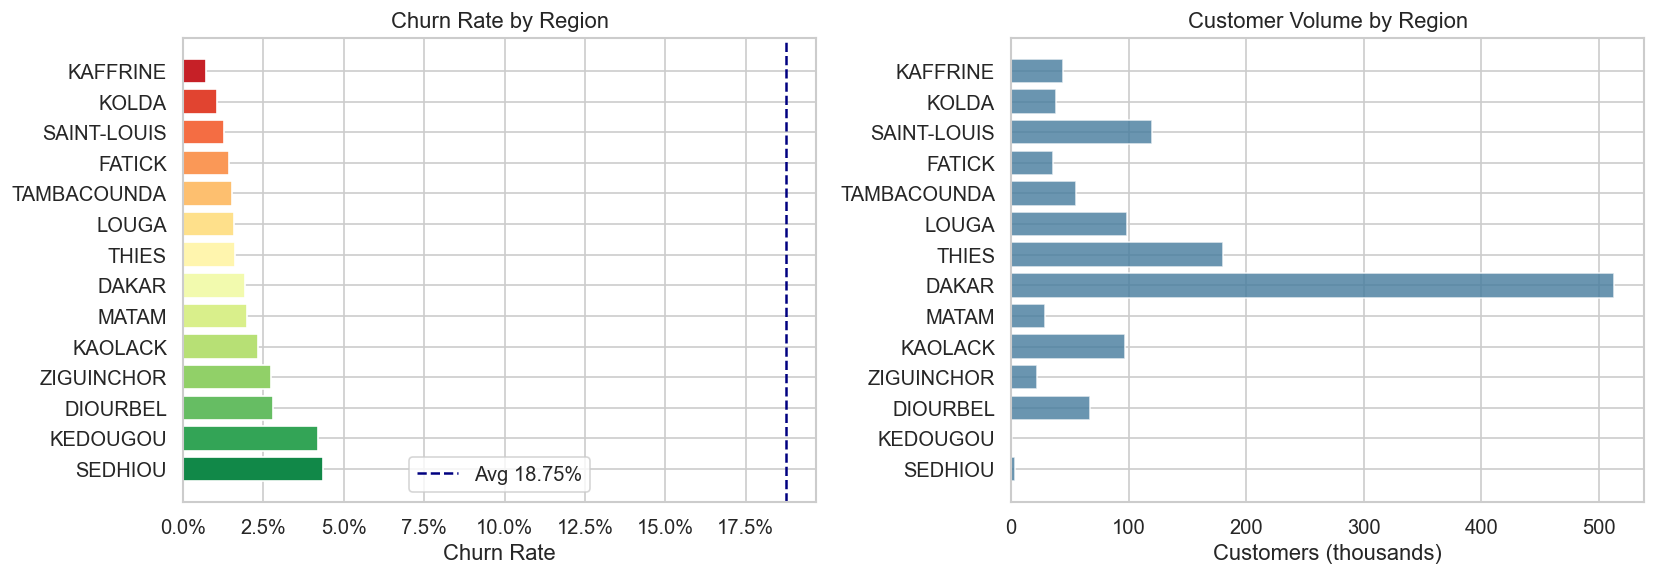

,churn_rate,n
REGION,,
SEDHIOU,0.0436,3119
KEDOUGOU,0.0422,1020
DIOURBEL,0.0281,66911
ZIGUINCHOR,0.0274,21945
KAOLACK,0.0234,96986
MATAM,0.0201,29083
DAKAR,0.0192,513271
THIES,0.0163,180052
LOUGA,0.0160,99053


In [8]:
# ── REGION: churn rate per region ─────────────────────────────────────────────
region_stats = (
    train.groupby('REGION', observed=True)['CHURN']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n'})
    .sort_values('churn_rate', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate
bars = axes[0].barh(region_stats.index, region_stats['churn_rate'],
                    color=sns.color_palette('RdYlGn_r', len(region_stats)))
axes[0].axvline(churn_rate, color='navy', ls='--', lw=1.5, label=f'Avg {churn_rate:.2%}')
axes[0].set_xlabel('Churn Rate')
axes[0].set_title('Churn Rate by Region')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Volume
axes[1].barh(region_stats.index, region_stats['n'] / 1000,
             color='#457B9D', alpha=0.8)
axes[1].set_xlabel('Customers (thousands)')
axes[1].set_title('Customer Volume by Region')

plt.tight_layout()
plt.show()
region_stats.round(4)

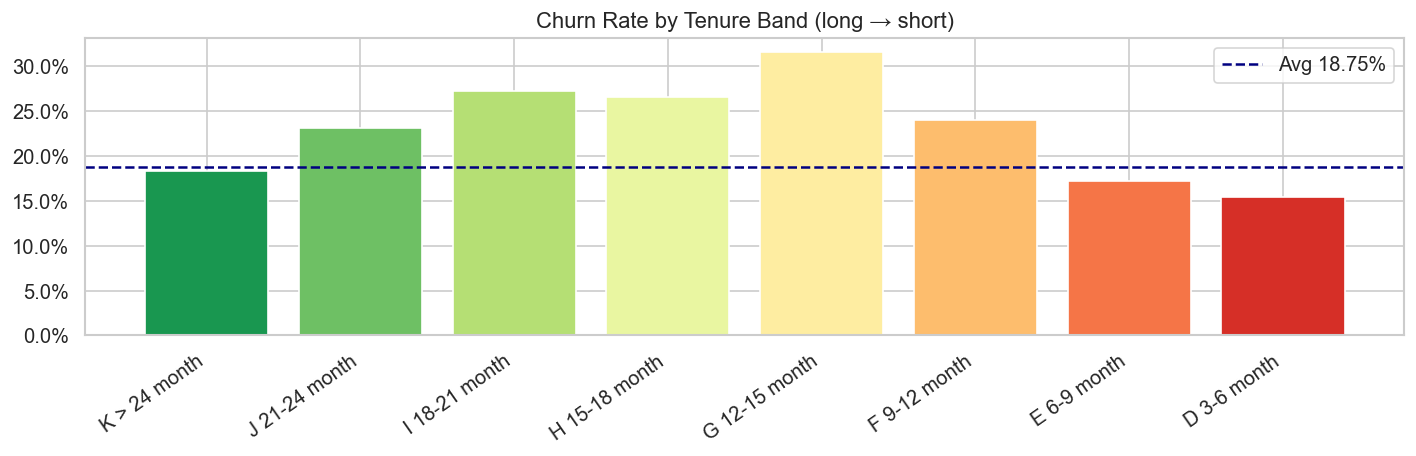

,churn_rate,n
TENURE,,
K > 24 month,0.1832,2043201
J 21-24 month,0.2309,12725
I 18-21 month,0.2727,45278
H 15-18 month,0.2662,26006
G 12-15 month,0.3163,14901
F 9-12 month,0.2401,9328
E 6-9 month,0.1718,1839
D 3-6 month,0.1545,770


In [9]:
# ── TENURE: ordered churn pattern ─────────────────────────────────────────────
tenure_order = [
    'K > 24 month', 'J 21-24 month', 'I 18-21 month', 'H 15-18 month',
    'G 12-15 month', 'F 9-12 month', 'E 6-9 month', 'D 3-6 month',
    'C 3 month',     'B 2 month',    'A < 2 month',
]
# keep only labels present in the data
tenure_present = [t for t in tenure_order if t in train['TENURE'].cat.categories]

tenure_stats = (
    train.groupby('TENURE', observed=True)['CHURN']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n'})
    .reindex(tenure_present)
)

fig, ax = plt.subplots(figsize=(12, 4))
color_map = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(tenure_stats)))
bars = ax.bar(tenure_stats.index, tenure_stats['churn_rate'], color=color_map)
ax.axhline(churn_rate, color='navy', ls='--', lw=1.5, label=f'Avg {churn_rate:.2%}')
ax.set_xticklabels(tenure_stats.index, rotation=35, ha='right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Churn Rate by Tenure Band (long → short)')
ax.legend()
plt.tight_layout()
plt.show()

tenure_stats.round(4)

MRG churn rates:


,churn_rate,n
MRG,,
NO,0.1875,2154048


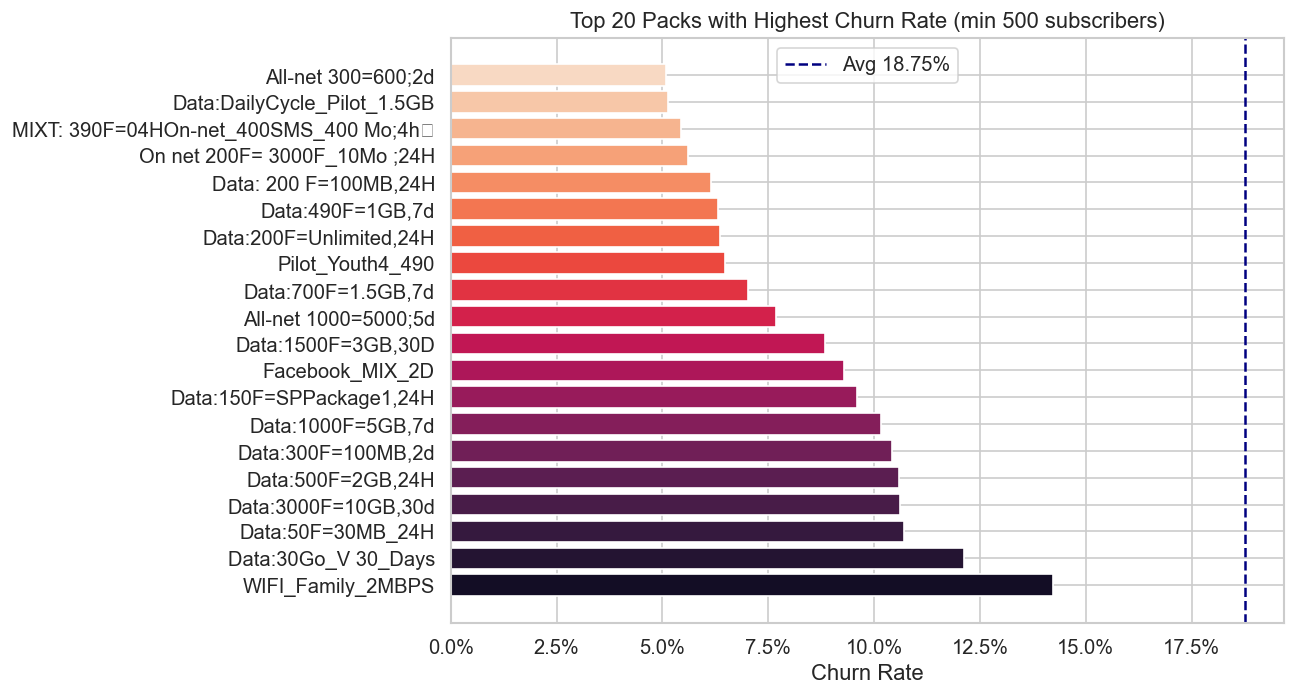

In [10]:
# ── MRG (VAS flag) ────────────────────────────────────────────────────────────
mrg_stats = (
    train.groupby('MRG', observed=True)['CHURN']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n'})
)
print('MRG churn rates:')
display(mrg_stats.round(4))

# TOP_PACK top-20 by churn rate
toppack_stats = (
    train.groupby('TOP_PACK', observed=True)['CHURN']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n'})
    .query('n >= 500')  # min support
    .sort_values('churn_rate', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(toppack_stats.index, toppack_stats['churn_rate'],
        color=sns.color_palette('rocket', len(toppack_stats)))
ax.axvline(churn_rate, color='navy', ls='--', lw=1.5, label=f'Avg {churn_rate:.2%}')
ax.set_xlabel('Churn Rate')
ax.set_title('Top 20 Packs with Highest Churn Rate (min 500 subscribers)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Numeric Features — Distributions & Outliers

In [11]:
NUM_COLS = [
    'MONTANT', 'FREQUENCE_RECH', 'REVENUE', 'ARPU_SEGMENT',
    'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
    'ZONE1', 'ZONE2', 'REGULARITY', 'FREQ_TOP_PACK'
]

desc = train[NUM_COLS].describe().T
desc['skewness'] = train[NUM_COLS].skew()
desc['kurtosis'] = train[NUM_COLS].kurt()
desc['pct_zero']  = (train[NUM_COLS] == 0).mean() * 100
desc['pct_missing'] = train[NUM_COLS].isna().mean() * 100
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,pct_zero,pct_missing
MONTANT,1397309.0000,5532.1170,7111.3390,10.0000,1000.0000,3000.0000,7350.0000,470000.0000,4.2300,57.5280,0.0000,35.1310
FREQUENCE_RECH,1397309.0000,11.5290,13.2740,1.0000,2.0000,7.0000,16.0000,133.0000,2.1120,5.3170,0.0000,35.1310
REVENUE,1428000.0000,5510.8100,7187.1130,1.0000,1000.0000,3000.0000,7368.0000,532177.0000,4.1890,64.8220,0.0000,33.7060
ARPU_SEGMENT,1428000.0000,1836.9430,2395.7000,0.0000,333.0000,1000.0000,2456.0000,177392.0000,4.1890,64.8220,0.1990,33.7060
FREQUENCE,1428000.0000,13.9780,14.6940,1.0000,3.0000,9.0000,20.0000,91.0000,1.7750,3.4030,0.0000,33.7060
DATA_VOLUME,1093615.0000,3366.4500,13304.4640,0.0000,0.0000,257.0000,2895.0000,1823866.0000,36.2570,2448.1240,14.8630,49.2300
ON_NET,1367373.0000,277.6890,872.6890,0.0000,5.0000,27.0000,156.0000,50809.0000,8.1480,116.8570,5.0160,36.5210
ORANGE,1258800.0000,95.4190,204.9870,0.0000,7.0000,29.0000,99.0000,21323.0000,8.0540,189.0390,2.8610,41.5610
TIGO,864032.0000,23.1090,63.5780,0.0000,2.0000,6.0000,20.0000,4174.0000,12.9000,334.6750,4.3760,59.8880
ZONE1,169721.0000,8.1700,41.1700,0.0000,0.0000,1.0000,3.0000,4792.0000,25.7090,1572.6890,2.7820,92.1210


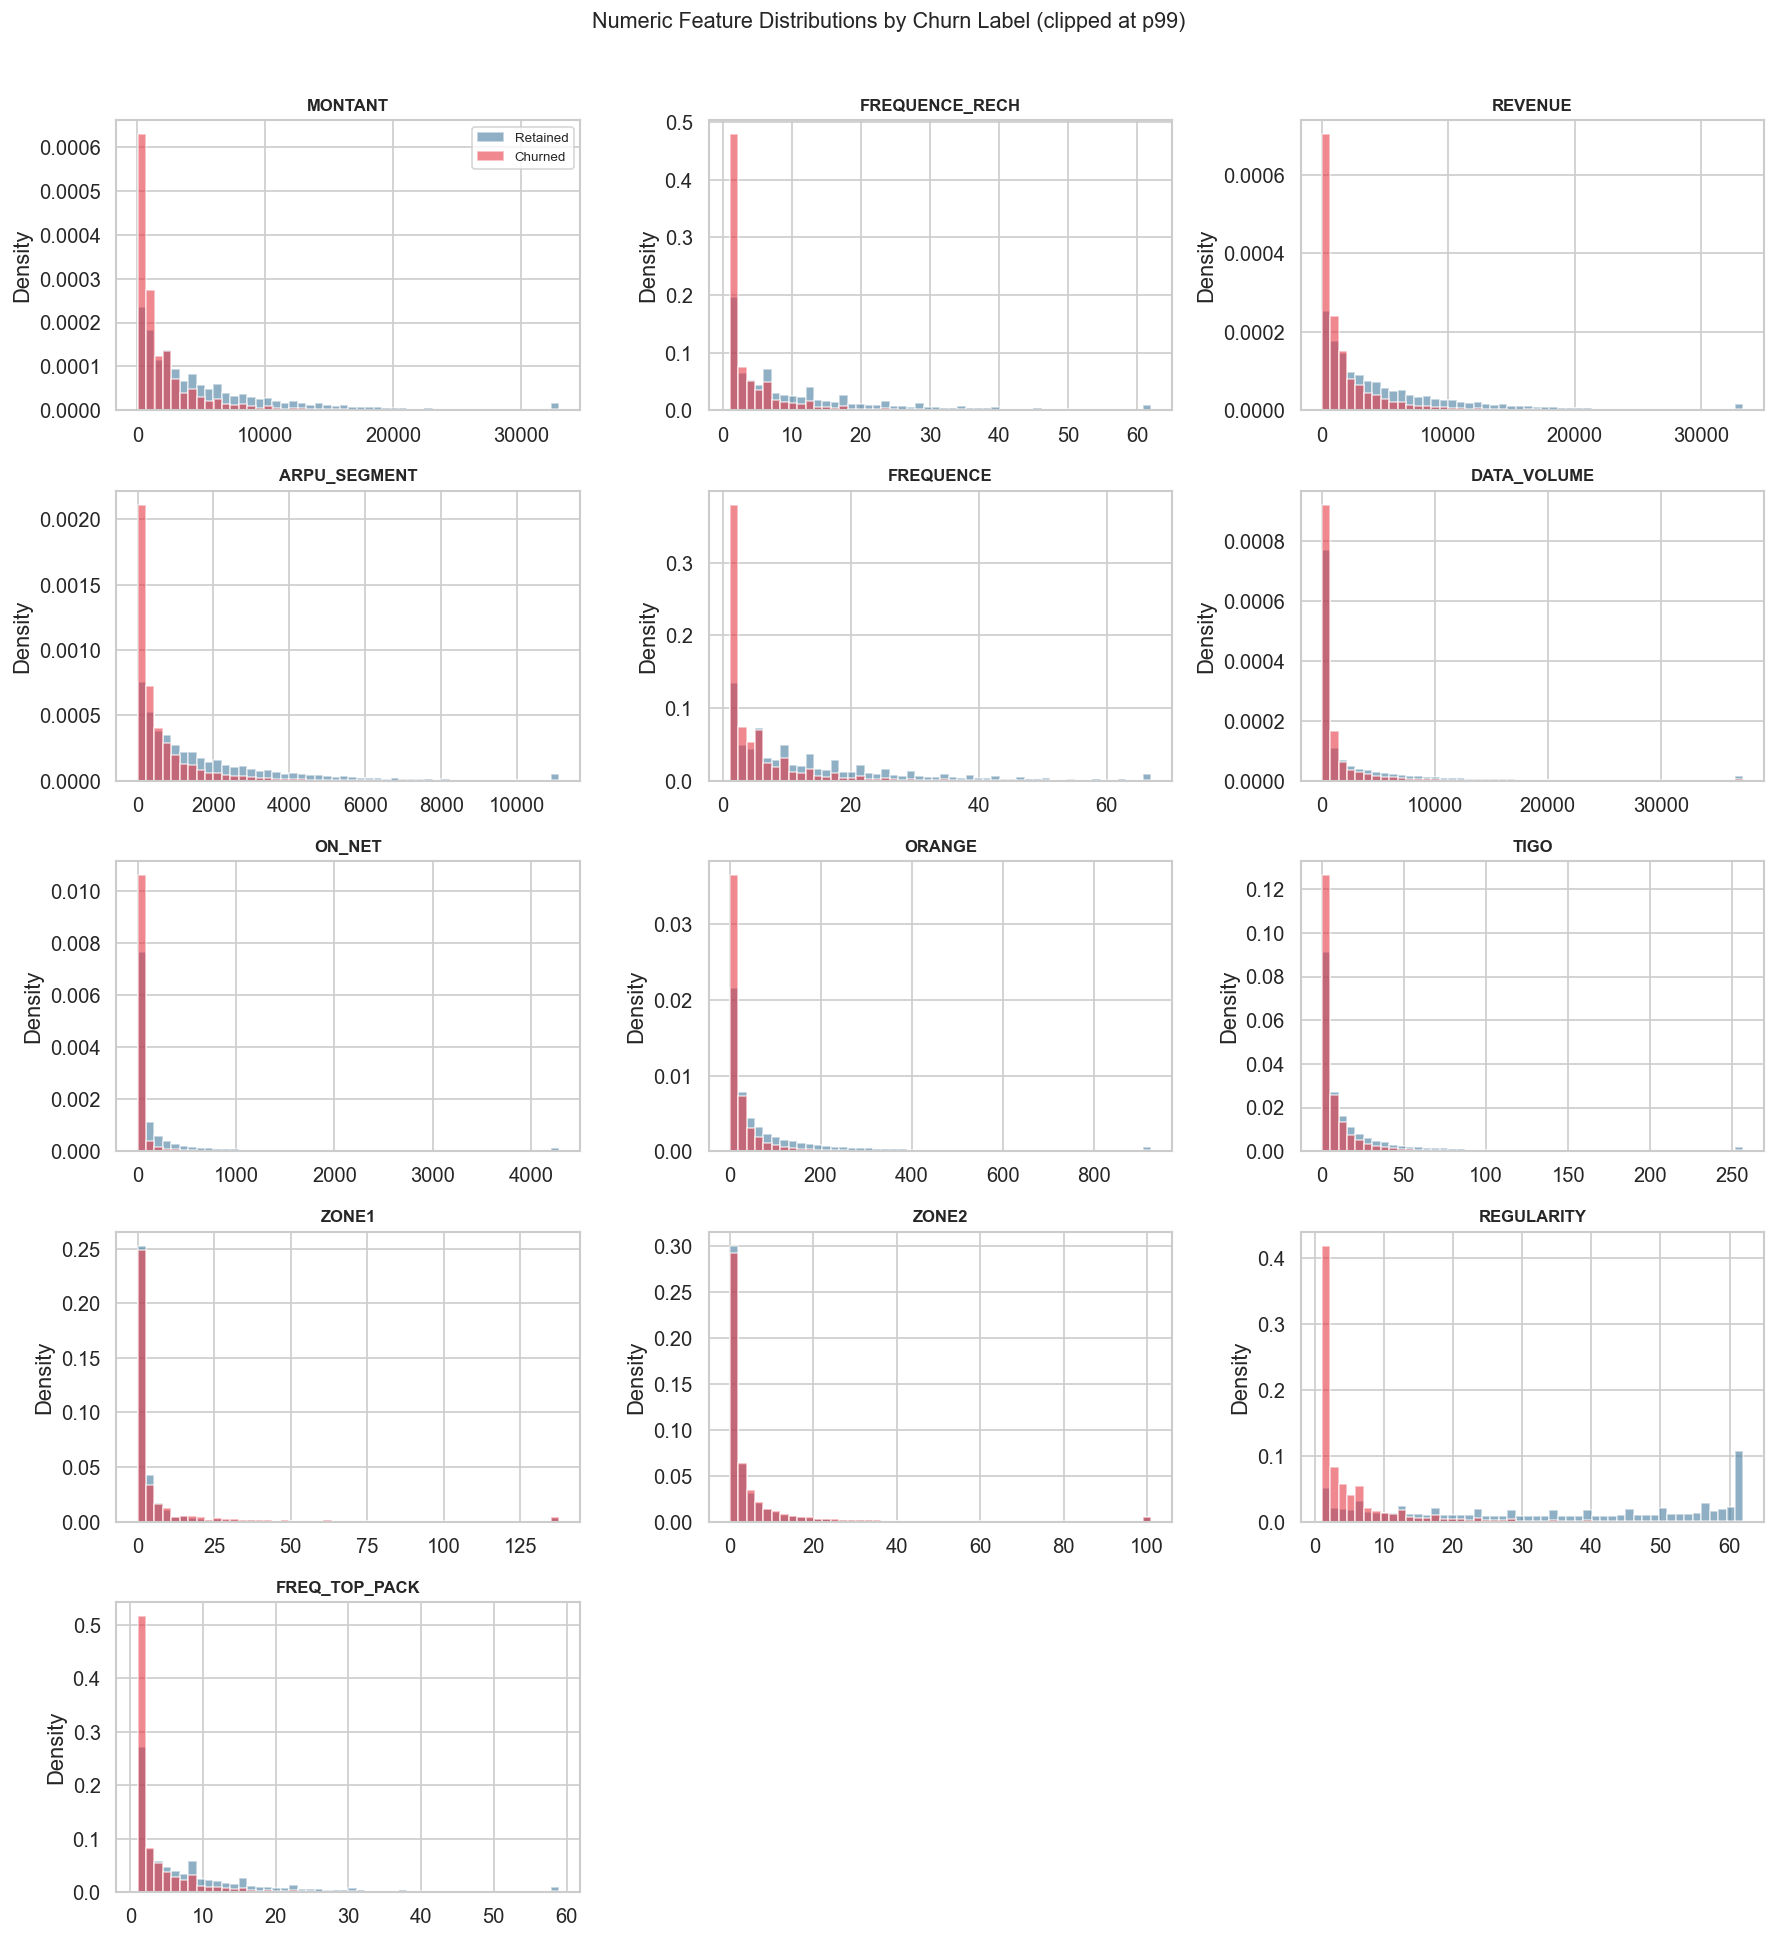

In [12]:
# Distribution plots: log-scale to handle extreme skew
n_cols = 3
n_rows = int(np.ceil(len(NUM_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.2))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    data_churn  = train.loc[train['CHURN'] == 1, col].dropna()
    data_retain = train.loc[train['CHURN'] == 0, col].dropna()

    # clip to 99th percentile to suppress extreme outliers in plot
    cap = train[col].quantile(0.99)
    data_churn  = data_churn.clip(upper=cap)
    data_retain = data_retain.clip(upper=cap)

    ax.hist(data_retain, bins=50, alpha=0.6, color=PALETTE['retain'],
            label='Retained', density=True)
    ax.hist(data_churn,  bins=50, alpha=0.6, color=PALETTE['churn'],
            label='Churned',  density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Churn Label (clipped at p99)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Median comparison: churn vs retain
medians = (
    train.groupby('CHURN')[NUM_COLS]
    .median()
    .T
    .rename(columns={0: 'retained_median', 1: 'churn_median'})
)
medians['ratio_churn_retain'] = (medians['churn_median'] / medians['retained_median'].replace(0, np.nan)).round(3)
medians.sort_values('ratio_churn_retain')

CHURN,retained_median,churn_median,ratio_churn_retain
REGULARITY,34.0000,2.0000,0.0590
ON_NET,30.0000,5.0000,0.1670
FREQUENCE,9.0000,2.0000,0.2220
REVENUE,3200.0000,826.0000,0.2580
ARPU_SEGMENT,1067.0000,275.0000,0.2580
DATA_VOLUME,286.0000,75.0000,0.2620
FREQUENCE_RECH,7.0000,2.0000,0.2860
ORANGE,30.0000,9.0000,0.3000
MONTANT,3250.0000,1000.0000,0.3080
FREQ_TOP_PACK,5.0000,2.0000,0.4000


In [14]:
# ── Outlier detection via IQR ─────────────────────────────────────────────────
outlier_report = {}
for col in NUM_COLS:
    q1, q3 = train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    n_out = ((train[col] < lo) | (train[col] > hi)).sum()
    outlier_report[col] = {
        'lower_fence': round(lo, 2),
        'upper_fence': round(hi, 2),
        'n_outliers': int(n_out),
        'pct_outliers': round(n_out / len(train) * 100, 3),
    }

pd.DataFrame(outlier_report).T.sort_values('pct_outliers', ascending=False)

,lower_fence,upper_fence,n_outliers,pct_outliers
ON_NET,-448.0000,609.0000,143868.0000,6.6790
DATA_VOLUME,-8685.0000,11580.0000,80325.0000,3.7290
ORANGE,-269.0000,375.0000,67708.0000,3.1430
TIGO,-52.0000,74.0000,59377.0000,2.7570
FREQ_TOP_PACK,-28.0000,42.0000,34455.0000,1.6000
REVENUE,-18104.0000,26472.0000,29088.0000,1.3500
ARPU_SEGMENT,-6036.0000,8825.0000,29078.0000,1.3500
MONTANT,-18050.0000,26400.0000,27611.0000,1.2820
FREQUENCE_RECH,-40.0000,58.0000,18926.0000,0.8790
ZONE1,-9.0000,12.0000,17732.0000,0.8230


## 6. Correlation & Multicollinearity

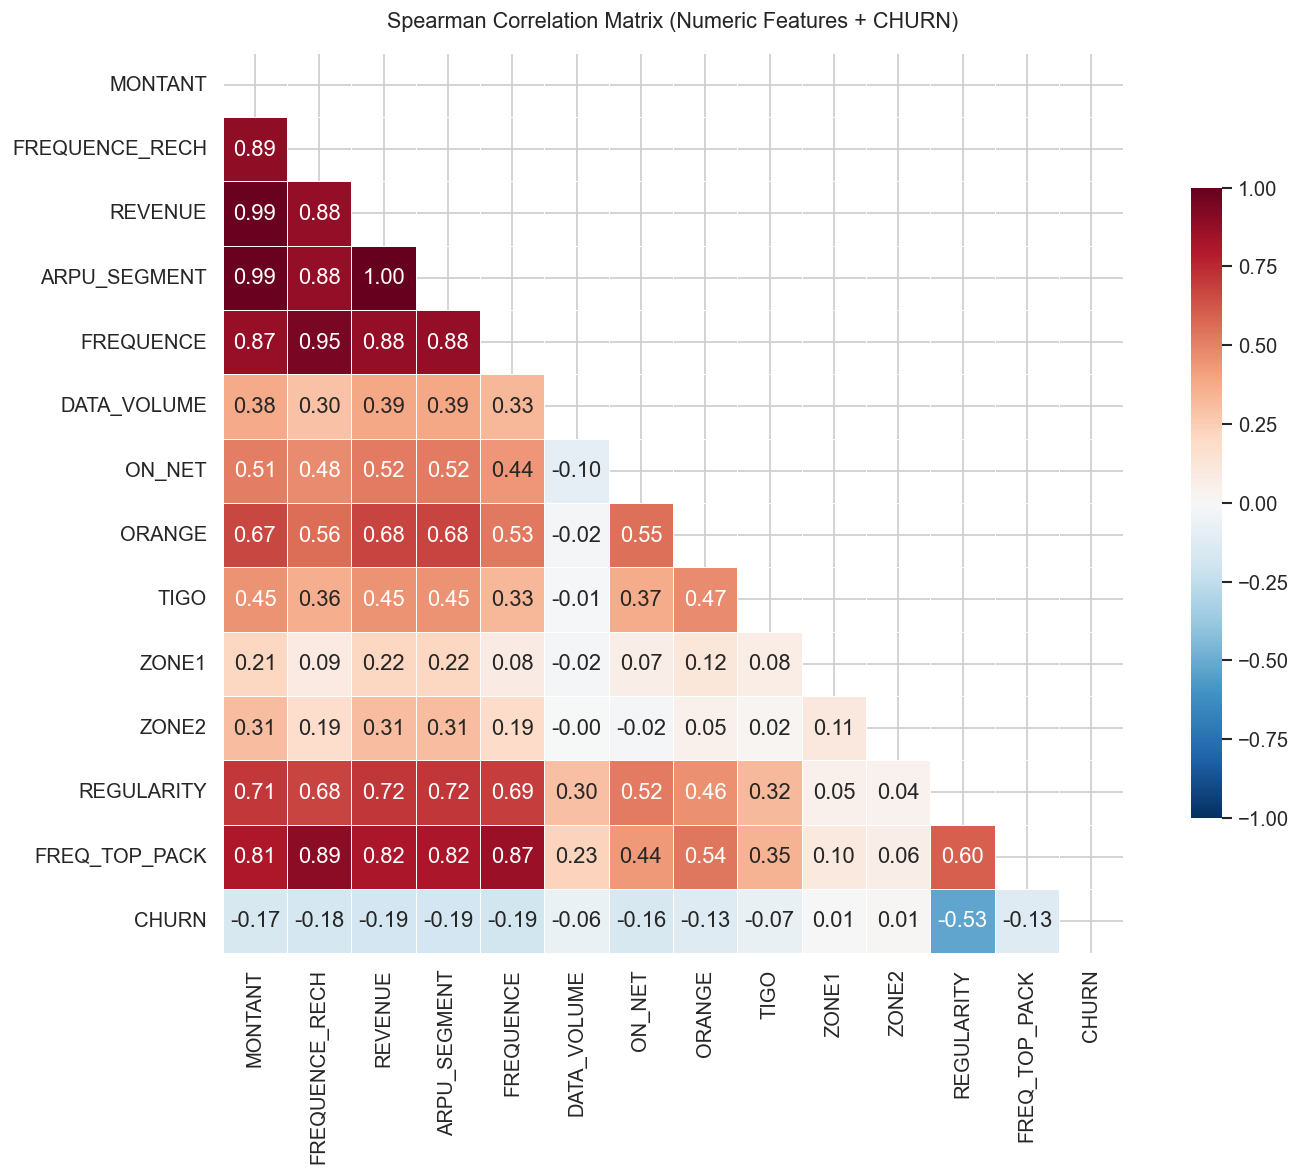

In [15]:
corr = train[NUM_COLS + ['CHURN']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.7},
    ax=ax,
)
ax.set_title('Spearman Correlation Matrix (Numeric Features + CHURN)', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

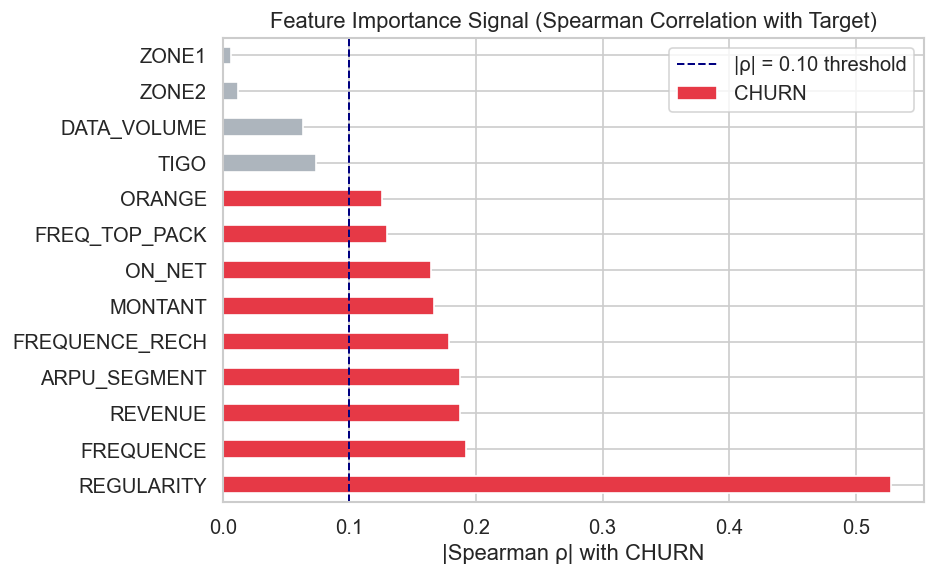

REGULARITY       0.5278
FREQUENCE        0.1921
REVENUE          0.1871
ARPU_SEGMENT     0.1870
FREQUENCE_RECH   0.1783
MONTANT          0.1665
ON_NET           0.1645
FREQ_TOP_PACK    0.1296
ORANGE           0.1254
TIGO             0.0733
DATA_VOLUME      0.0636
ZONE2            0.0122
ZONE1            0.0061


In [16]:
# Features most correlated with CHURN (absolute Spearman)
churn_corr = (
    corr['CHURN']
    .drop('CHURN')
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
churn_corr.plot(kind='barh', ax=ax,
                color=['#E63946' if v > 0.1 else '#ADB5BD' for v in churn_corr.values])
ax.axvline(0.1, color='navy', ls='--', lw=1.2, label='|ρ| = 0.10 threshold')
ax.set_xlabel('|Spearman ρ| with CHURN')
ax.set_title('Feature Importance Signal (Spearman Correlation with Target)')
ax.legend()
plt.tight_layout()
plt.show()

print(churn_corr.to_string())

In [17]:
# ── Highly co-linear feature pairs (|ρ| > 0.85) ──────────────────────────────
high_corr_pairs = []
for i, c1 in enumerate(NUM_COLS):
    for c2 in NUM_COLS[i+1:]:
        r = corr.loc[c1, c2]
        if abs(r) >= 0.85:
            high_corr_pairs.append({'feature_1': c1, 'feature_2': c2, 'spearman_rho': round(r, 3)})

if high_corr_pairs:
    print('Highly collinear pairs (|ρ| ≥ 0.85):')
    display(pd.DataFrame(high_corr_pairs).sort_values('spearman_rho', ascending=False))
else:
    print('No highly collinear pairs found at |ρ| ≥ 0.85')

Highly collinear pairs (|ρ| ≥ 0.85):


,feature_1,feature_2,spearman_rho
8,REVENUE,ARPU_SEGMENT,1.0000
1,MONTANT,REVENUE,0.9870
2,MONTANT,ARPU_SEGMENT,0.9870
6,FREQUENCE_RECH,FREQUENCE,0.9510
7,FREQUENCE_RECH,FREQ_TOP_PACK,0.8940
0,MONTANT,FREQUENCE_RECH,0.8870
9,REVENUE,FREQUENCE,0.8800
10,ARPU_SEGMENT,FREQUENCE,0.8800
4,FREQUENCE_RECH,REVENUE,0.8790
5,FREQUENCE_RECH,ARPU_SEGMENT,0.8790


## 7. REGULARITY Deep-Dive

REGULARITY (activity count over 90 days, max = 90) is expected to be the strongest predictor.

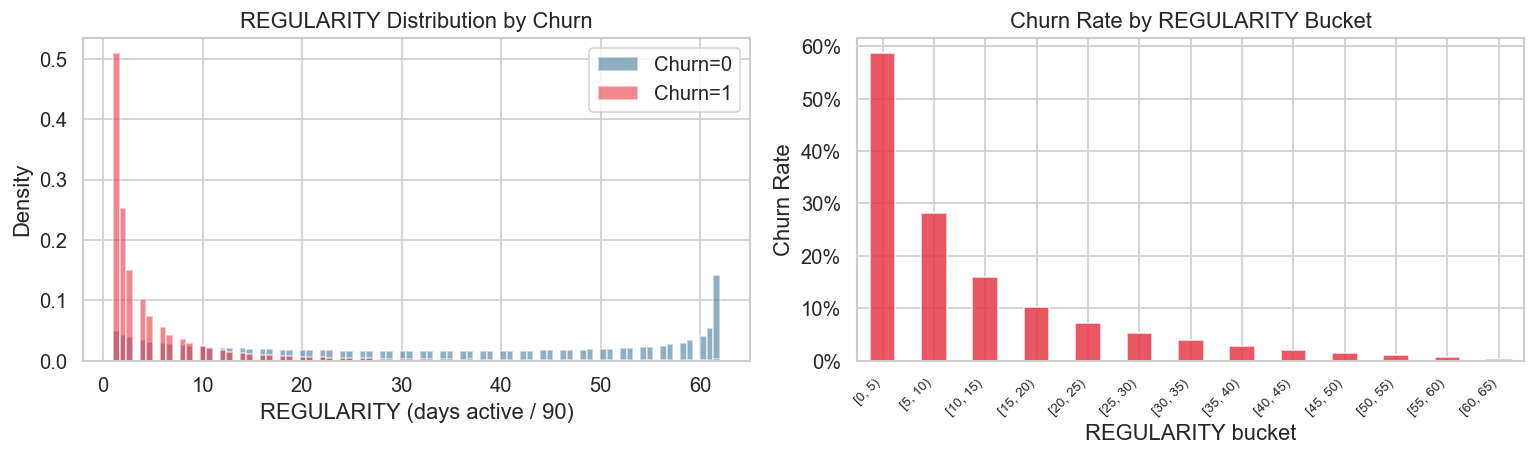

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution by churn
for label, grp in train.groupby('CHURN'):
    axes[0].hist(
        grp['REGULARITY'].dropna(),
        bins=91, alpha=0.6,
        label=f'Churn={label}',
        color=PALETTE['churn'] if label == 1 else PALETTE['retain'],
        density=True,
    )
axes[0].set_xlabel('REGULARITY (days active / 90)')
axes[0].set_ylabel('Density')
axes[0].set_title('REGULARITY Distribution by Churn')
axes[0].legend()

# Churn rate by regularity bucket
train['reg_bucket'] = pd.cut(train['REGULARITY'], bins=range(0, 96, 5), right=False)
reg_churn = train.groupby('reg_bucket', observed=True)['CHURN'].mean()
reg_churn.plot(kind='bar', ax=axes[1], color='#E63946', alpha=0.85, edgecolor='white')
axes[1].set_xticklabels([str(b) for b in reg_churn.index], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Churn Rate')
axes[1].set_xlabel('REGULARITY bucket')
axes[1].set_title('Churn Rate by REGULARITY Bucket')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()
train.drop(columns=['reg_bucket'], inplace=True)

## 8. Revenue & ARPU Segment Analysis

REVENUE vs ARPU_SEGMENT×3 — mean abs diff: 0.6848
Rows where |diff| < 1 (exact match): 31.52%


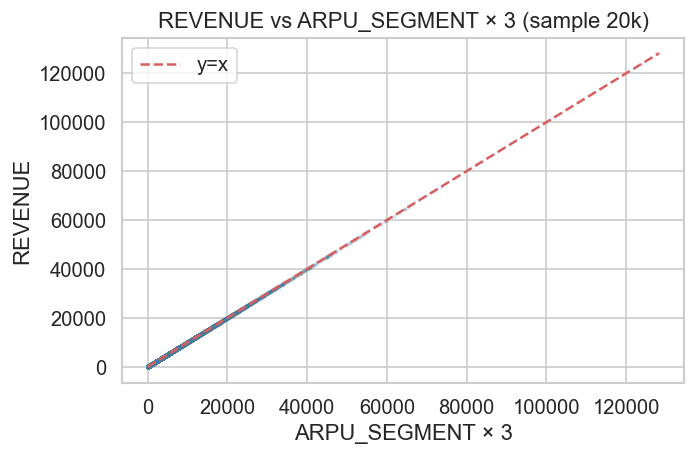

In [19]:
# Check REVENUE ≈ ARPU_SEGMENT × 3 relationship
valid = train[['REVENUE', 'ARPU_SEGMENT']].dropna()
implied = valid['ARPU_SEGMENT'] * 3
diff = (valid['REVENUE'] - implied).abs()
print(f'REVENUE vs ARPU_SEGMENT×3 — mean abs diff: {diff.mean():.4f}')
print(f'Rows where |diff| < 1 (exact match): {(diff < 1).mean():.2%}')

# Scatter sample
sample = valid.sample(n=min(20_000, len(valid)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sample['ARPU_SEGMENT'] * 3, sample['REVENUE'], alpha=0.1, s=2, color='#457B9D')
ax.plot([0, sample['REVENUE'].max()], [0, sample['REVENUE'].max()], 'r--', lw=1.5, label='y=x')
ax.set_xlabel('ARPU_SEGMENT × 3')
ax.set_ylabel('REVENUE')
ax.set_title('REVENUE vs ARPU_SEGMENT × 3 (sample 20k)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Train / Test Feature Distribution Alignment

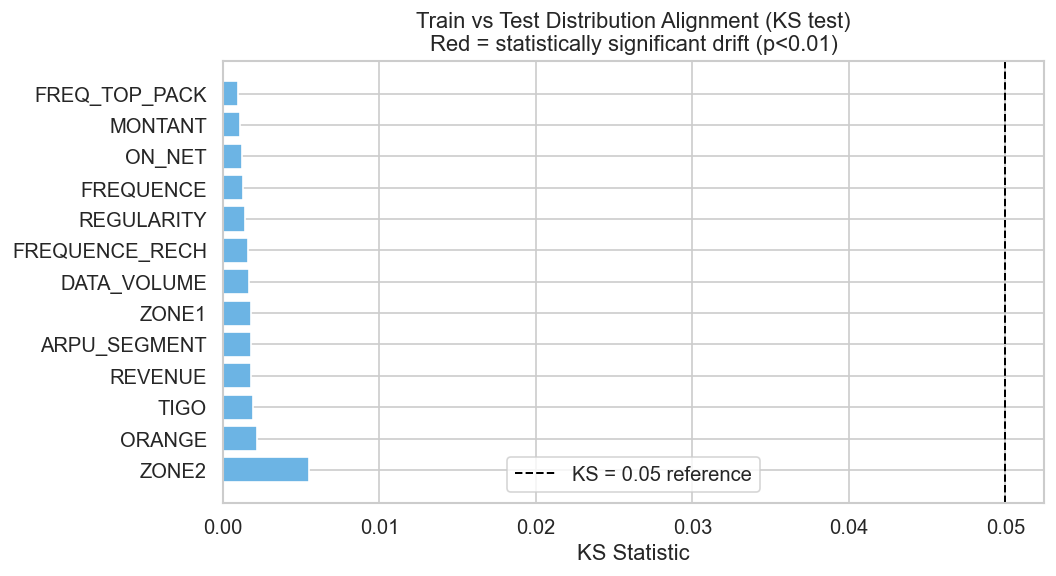

,ks_stat,p_value,drift
ZONE2,0.0055,0.5658,False
ORANGE,0.0022,0.3393,False
TIGO,0.0019,0.7423,False
REVENUE,0.0018,0.5038,False
ARPU_SEGMENT,0.0018,0.5038,False
ZONE1,0.0018,1.0000,False
DATA_VOLUME,0.0017,0.6962,False
FREQUENCE_RECH,0.0016,0.6339,False
REGULARITY,0.0014,0.5083,False
FREQUENCE,0.0013,0.8869,False


In [20]:
# KS test to check distribution shift between train and test
from scipy.stats import ks_2samp

ks_results = {}
for col in NUM_COLS:
    tr = train[col].dropna().values
    te = test[col].dropna().values
    stat, p = ks_2samp(tr, te, alternative='two-sided')
    ks_results[col] = {'ks_stat': round(stat, 4), 'p_value': round(p, 6), 'drift': p < 0.01}

ks_df = pd.DataFrame(ks_results).T.sort_values('ks_stat', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E63946' if d else '#6CB4E4' for d in ks_df['drift']]
ax.barh(ks_df.index, ks_df['ks_stat'].astype(float), color=colors)
ax.axvline(0.05, color='black', ls='--', lw=1.2, label='KS = 0.05 reference')
ax.set_xlabel('KS Statistic')
ax.set_title('Train vs Test Distribution Alignment (KS test)\nRed = statistically significant drift (p<0.01)')
ax.legend()
plt.tight_layout()
plt.show()

ks_df

## 10. Duplicate & Data Quality Checks

In [21]:
print('=== Data Quality Summary ===')
print(f'Train rows         : {len(train):,}')
print(f'Duplicate user_ids : {train["user_id"].duplicated().sum():,}')
print(f'Null user_ids      : {train["user_id"].isna().sum():,}')
print()

# Negative values in non-negative features
neg_counts = {}
for col in NUM_COLS:
    n_neg = (train[col] < 0).sum()
    if n_neg > 0:
        neg_counts[col] = n_neg

if neg_counts:
    print('Negative values in numeric features:')
    for col, n in neg_counts.items():
        print(f'  {col}: {n:,} ({n/len(train):.3%})')
else:
    print('No negative values found in numeric features.')

# REGULARITY bounds check (should be 0–90)
out_of_range = ((train['REGULARITY'] < 0) | (train['REGULARITY'] > 90)).sum()
print(f'\nREGULARITY out of [0,90] range: {out_of_range:,}')

=== Data Quality Summary ===
Train rows         : 2,154,048
Duplicate user_ids : 0
Null user_ids      : 0

No negative values found in numeric features.

REGULARITY out of [0,90] range: 0


## 11. EDA Findings & Feature Engineering Roadmap

### Key Findings

| # | Finding | Impact |
|---|---------|--------|
| 1 | **Severe class imbalance** (~18–20% churn rate, 1:4–5 ratio) | Must use `scale_pos_weight` in XGBoost or SMOTE for LightGBM; optimize for AUC-ROC + F1 |
| 2 | **REGULARITY is the dominant predictor** — churners have dramatically lower regularity | Create binary `is_inactive` flag (REGULARITY < 10) and `regularity_rate` = REGULARITY/90 |
| 3 | **Massive missingness** in DATA_VOLUME, ON_NET, ORANGE, TIGO, ZONE1, ZONE2, FREQ_TOP_PACK, TOP_PACK | Missing = *never used that service* → impute with 0 (MNAR), add `_missing` indicator flags |
| 4 | **REVENUE ≈ ARPU_SEGMENT × 3** — near-perfect linear relationship → collinear | Drop ARPU_SEGMENT or use it only to derive a monthly ARPU feature; avoid feeding both to tree models |
| 5 | **TENURE has strong monotonic signal** — new subscribers (< 3 months) churn far more than loyalists | Ordinal-encode TENURE; create `is_new_subscriber` (TENURE ≤ 'C 3 month') |
| 6 | **Regional variation in churn** — some regions exceed 2× the average churn rate | Include as a target-encoded feature with k-fold smoothing |
| 7 | **TOP_PACK is high-cardinality** (100+ unique values) — some packs strongly predict churn | Target-encode with frequency cap; create `top_pack_churn_rate` |
| 8 | **Extreme right-skew** across all numeric features (skewness > 5 for most) | Log1p transform for LR/NN baselines; not needed for tree models |
| 9 | **Zero inflation** in call features (ON_NET, ORANGE, TIGO, ZONE1, ZONE2) — many customers have 0 calls | Create `total_calls` aggregate and `n_active_call_types` count feature |
| 10 | **No significant train/test distribution drift** (KS statistics small) | Training distribution generalises; no special domain adaptation needed |

### Feature Engineering Roadmap

**Derived Numeric Features**
- `regularity_rate` = REGULARITY / 90
- `recharge_per_freq` = MONTANT / (FREQUENCE_RECH + 1)
- `revenue_per_freq` = REVENUE / (FREQUENCE + 1)
- `total_calls` = ON_NET + ORANGE + TIGO + ZONE1 + ZONE2
- `n_active_call_types` = count of non-zero call columns
- `data_user` = binary (DATA_VOLUME > 0)
- `arpu_monthly` = ARPU_SEGMENT (already monthly; drop REVENUE to reduce collinearity)

**Binary Flags**
- `is_new_subscriber` (TENURE in earliest 2 bands)
- `is_inactive` (REGULARITY < 5)
- `has_data` (DATA_VOLUME > 0)
- `_missing` indicator columns for all high-missingness features

**Categorical Encodings**
- TENURE → ordinal integer (order by duration)
- REGION → target-encoded (k-fold, smoothed)
- TOP_PACK → frequency + target encoding; rare pack → 'OTHER'
- MRG → binary (YES=1)

**Imputation Strategy**
- Call/data usage features (MNAR) → impute 0
- MONTANT, FREQUENCE_RECH, REVENUE (MAR) → median imputation
- TOP_PACK missing → 'UNKNOWN' category

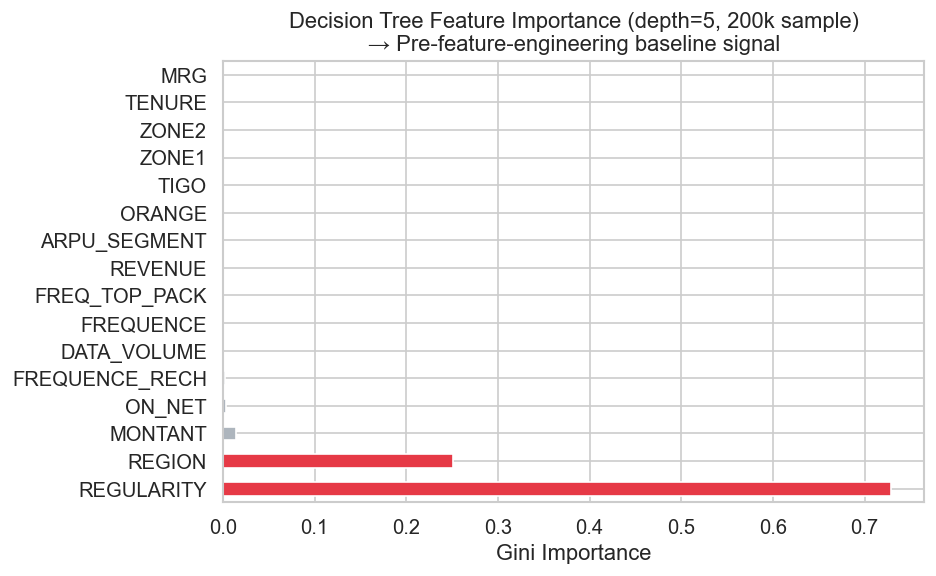

REGULARITY       0.7290
REGION           0.2507
MONTANT          0.0141
ON_NET           0.0035
FREQUENCE_RECH   0.0019
DATA_VOLUME      0.0007
FREQUENCE        0.0001
FREQ_TOP_PACK    0.0000
REVENUE          0.0000
ARPU_SEGMENT     0.0000
ORANGE           0.0000
TIGO             0.0000
ZONE1            0.0000
ZONE2            0.0000
TENURE           0.0000
MRG              0.0000
dtype: float64

In [22]:
# ── Quick sanity-check: feature importance signal via permutation test ─────────
# Use a single decision tree to get a rough feature ranking (fast)
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import sklearn
sklearn.set_config(transform_output='pandas')

SAMPLE_N = 200_000
sample_df = train.sample(n=SAMPLE_N, random_state=RANDOM_STATE)

feature_cols = NUM_COLS + ['REGION', 'TENURE', 'MRG']
X = sample_df[feature_cols].copy()
y = sample_df['CHURN']

# Simple preprocessing: median + ordinal for categoricals
for col in ['REGION', 'TENURE', 'MRG']:
    X[col] = X[col].astype(str)

from sklearn.compose import ColumnTransformer
num_pipe = Pipeline([('imp', SimpleImputer(strategy='median'))])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])

pre = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('cat', cat_pipe, ['REGION', 'TENURE', 'MRG']),
])

clf = Pipeline([
    ('pre', pre),
    ('clf', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
])
clf.fit(X, y)

importances = clf.named_steps['clf'].feature_importances_
feat_names  = NUM_COLS + ['REGION', 'TENURE', 'MRG']
imp_df = pd.Series(importances, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
imp_df.plot(kind='barh', ax=ax, color=['#E63946' if v > 0.05 else '#ADB5BD' for v in imp_df.values])
ax.set_xlabel('Gini Importance')
ax.set_title('Decision Tree Feature Importance (depth=5, 200k sample)\n→ Pre-feature-engineering baseline signal')
plt.tight_layout()
plt.show()

imp_df

In [23]:
print('EDA complete. All findings documented above.')
print('Next step: 02_feature_engineering.ipynb')

EDA complete. All findings documented above.
Next step: 02_feature_engineering.ipynb
